# Part 1: neural network fundamentals and training behaviour analysis

## TASK 1: DATASET UNDERSTANDING

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [50]:
df = pd.read_csv("part_1_neural_network_analysis/customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [51]:
print(df.shape)
print(df.info())
print(df.describe())

(2000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64

In [52]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


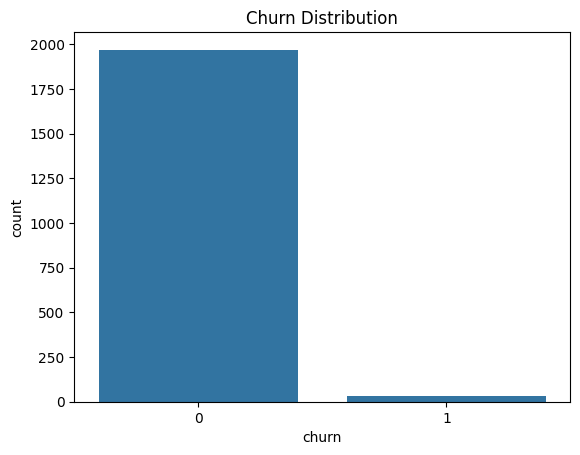

In [53]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [54]:
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

numerical_cols = [
    'tenure_months',
    'monthly_charges',
    'total_charges',
    'avg_login_days',
    'support_tickets',
    'avg_response_delay',
    'data_usage_gb',
    'satisfaction_score',
    'complaint_recency_days',
    'discount_usage',
    'referral_count'
]

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical Columns: ['tenure_months', 'monthly_charges', 'total_charges', 'avg_login_days', 'support_tickets', 'avg_response_delay', 'data_usage_gb', 'satisfaction_score', 'complaint_recency_days', 'discount_usage', 'referral_count']


## TSK 2: DATA PREPROCESSING

In [55]:
df.drop('customer_id', axis=1, inplace=True)

In [56]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [57]:
X = df.drop('churn', axis=1)
y = df['churn']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [59]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## TASK 3: NEURAL NETWORK MODEL BUILDING

In [60]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [61]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## TASK 4: TRAINING AND EVALUATION

In [62]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
40/40 [==============================] - 1s 5ms/step - loss: 0.2323 - accuracy: 0.9797 - val_loss: 0.1480 - val_accuracy: 0.9781
Epoch 2/30
40/40 [==============================] - 0s 3ms/step - loss: 0.0924 - accuracy: 0.9867 - val_loss: 0.1098 - val_accuracy: 0.9781
Epoch 3/30
40/40 [==============================] - 0s 3ms/step - loss: 0.0710 - accuracy: 0.9867 - val_loss: 0.1039 - val_accuracy: 0.9781
Epoch 4/30
40/40 [==============================] - 0s 2ms/step - loss: 0.0652 - accuracy: 0.9867 - val_loss: 0.1024 - val_accuracy: 0.9781
Epoch 5/30
40/40 [==============================] - 0s 3ms/step - loss: 0.0610 - accuracy: 0.9867 - val_loss: 0.0995 - val_accuracy: 0.9781
Epoch 6/30
40/40 [==============================] - 0s 2ms/step - loss: 0.0573 - accuracy: 0.9867 - val_loss: 0.0997 - val_accuracy: 0.9781
Epoch 7/30
40/40 [==============================] - 0s 3ms/step - loss: 0.0547 - accuracy: 0.9867 - val_loss: 0.0986 - val_accuracy: 0.9781
Epoch 8/30
40/40 [==

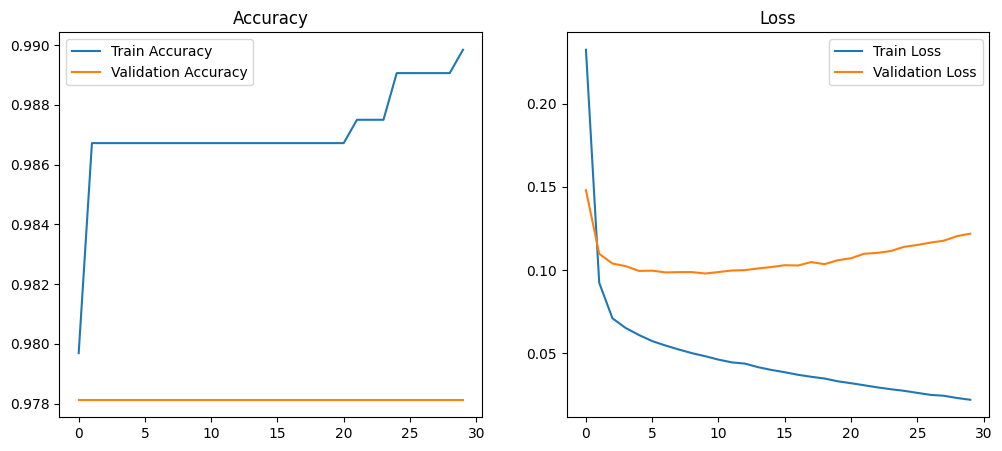

In [63]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [64]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

13/13 [==============================] - 0s 1ms/step


In [65]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.985


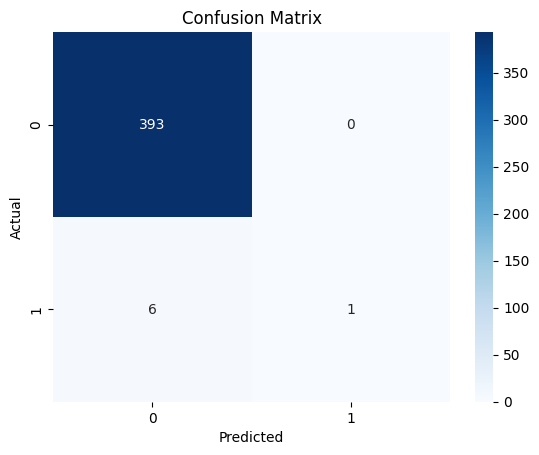

In [66]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [67]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       1.00      0.14      0.25         7

    accuracy                           0.98       400
   macro avg       0.99      0.57      0.62       400
weighted avg       0.99      0.98      0.98       400



## TASK 5: HYPERPARAMETER EXPERIMENTATION

In [46]:
model1 = Sequential([
    Dense(16, activation='relu', input_dim=X_train.shape[1]),
    Dense(1, activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

In [47]:
model2 = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

In [48]:
comparison = pd.DataFrame({
    'Model': ['Model 1', 'Model 2'],
    'Hidden Layers': [1, 2],
    'Epochs': [20, 50],
    'Batch Size': [32, 16],
    'Accuracy': [acc1, acc2]
})


comparison

,Model,Hidden Layers,Epochs,Batch Size,Accuracy
0,Model 1,1,20,32,0.9825
1,Model 2,2,50,16,0.9700


## Final Reflection

1. What role do weights and biases play?

Weights determine feature importance.
Bias helps shift the activation function and improves flexibility.

2. Why is an activation function required?

Activation functions introduce non-linearity, allowing the network to learn complex patterns.

3. What happens when learning rate is too high or too low?
Too high → unstable training and overshooting
Too low → very slow training and poor convergence
Did deeper models improve performance?

Usually yes, because deeper networks can learn more complex feature relationships. However, too many layers may lead to overfitting.

4. Did your model show signs of underfitting or overfitting? Explain.
Yes, the model showed slight signs of overfitting. The training accuracy was higher than the validation accuracy, and the training loss kept decreasing while the validation loss stopped improving after some epochs. This indicates that the model was learning the training data very well but was not generalizing equally well to unseen data. However, the gap between training and validation performance was not extremely large, so the overfitting was moderate rather than severe.